In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("ASIANPAINT.csv")

In [3]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,ASIANPAINT,EQ,361.20,370.0,390.0,370.0,385.0,381.65,380.54,3318,1.262617e+11,NaN,NaN,NaN
1,2000-01-04,ASIANPAINT,EQ,381.65,380.0,392.0,375.0,390.0,385.55,383.50,4818,1.847699e+11,NaN,NaN,NaN
2,2000-01-05,ASIANPAINT,EQ,385.55,371.5,390.0,371.5,383.0,383.00,379.81,2628,9.981384e+10,NaN,NaN,NaN
3,2000-01-06,ASIANPAINT,EQ,383.00,384.9,384.9,374.5,375.1,377.50,379.88,3354,1.274114e+11,NaN,NaN,NaN
4,2000-01-07,ASIANPAINT,EQ,377.50,376.0,390.0,370.0,389.0,385.70,383.38,9589,3.676275e+11,NaN,NaN,NaN


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [6]:
data = df[['Open', 'High', 'Low', 'Close', 'Volume']]

data = data.dropna()

print(data.head())

    Open   High    Low   Close  Volume
0  370.0  390.0  370.0  381.65    3318
1  380.0  392.0  375.0  385.55    4818
2  371.5  390.0  371.5  383.00    2628
3  384.9  384.9  374.5  377.50    3354
4  376.0  390.0  370.0  385.70    9589


In [7]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(5306, 5)


In [8]:
X = []
y = []

time_steps = 60

for i in range(time_steps, len(scaled_data)):
    
    X.append(scaled_data[i-time_steps:i])
    
    # Close column index = 3
    y.append(scaled_data[i, 3])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(5246, 60, 5)
(5246,)


In [9]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(4196, 60, 5)
(1050, 60, 5)


In [10]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(25))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

c:\Users\koushik\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,595 (205.45 KB)

 Trainable params: 52,595 (205.45 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0015 - val_loss: 1.1205e-04
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 0.0014 - val_loss: 1.2392e-04
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0014 - val_loss: 9.1477e-05
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 9.9988e-04 - val_loss: 8.2461e-05
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 9.2531e-04 - val_loss: 8.6602e-05
Epoch 9/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.0010 - val_loss: 1.3012e-04
Epoch 10/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 8.9766e-04 - val_loss: 3.2483e-04
Epoch 11/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0010 - val_loss: 1.1087

In [12]:
predictions = model.predict(X_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


In [13]:
dummy_pred = np.zeros((len(predictions), 5))
dummy_pred[:,3] = predictions[:,0]

predicted_close = scaler.inverse_transform(dummy_pred)[:,3]

dummy_actual = np.zeros((len(y_test), 5))
dummy_actual[:,3] = y_test

actual_close = scaler.inverse_transform(dummy_actual)[:,3]

In [14]:
rmse = np.sqrt(
    mean_squared_error(
        actual_close,
        predicted_close
    )
)

print("RMSE:", rmse)

RMSE: 102.94456910894912


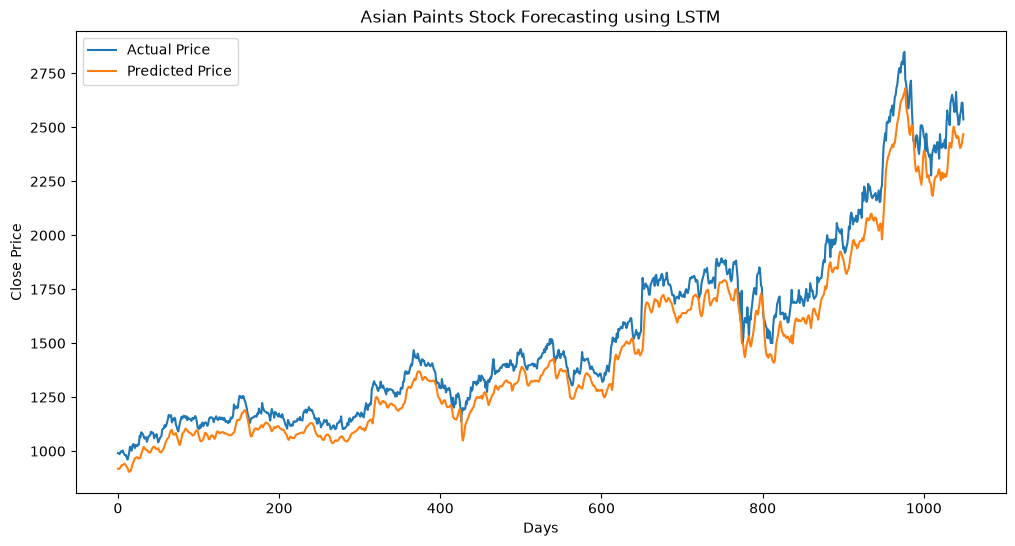

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    actual_close,
    label="Actual Price"
)

plt.plot(
    predicted_close,
    label="Predicted Price"
)

plt.title("Asian Paints Stock Forecasting using LSTM")

plt.xlabel("Days")

plt.ylabel("Close Price")

plt.legend()

plt.show()

In [16]:
last_60 = scaled_data[-60:]

last_60 = np.expand_dims(
    last_60,
    axis=0
)

tomorrow_scaled = model.predict(last_60)

dummy = np.zeros((1,5))

dummy[:,3] = tomorrow_scaled[:,0]

tomorrow_price = scaler.inverse_transform(dummy)[0,3]

print("Predicted Next Day Close Price:")
print(tomorrow_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Predicted Next Day Close Price:
2459.3353684902195
